# Loading Datasets from Kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sandipacharya10","key":"65a6aa6e722edf2e6678c7f9476c23ac"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!pip install kaggle


In [ ]:
!kaggle datasets download -d ishworsubedii/vehicle-number-plate-datasetnepal

Dataset URL: https://www.kaggle.com/datasets/ishworsubedii/vehicle-number-plate-datasetnepal
License(s): apache-2.0
100% 795M/795M [00:47<00:00, 17.7MB/s]
100% 795M/795M [00:47<00:00, 17.7MB/s]


In [ ]:
!unzip <vehicle-number-plate-datasetnepal.zip> -d /content/vehicle-number-plate-datasetnepal

replace vehicle_number_plate_detection/images/2024-03-08_1002_0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: error:  invalid response [PK-]
replace vehicle_number_plate_detection/images/2024-03-08_1002_0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: error:  invalid response []
replace vehicle_number_plate_detection/images/2024-03-08_1002_0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: error:  invalid response [��������;]
replace vehicle_number_plate_detection/images/2024-03-08_1002_0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: error:  invalid response []
replace vehicle_number_plate_detection/images/2024-03-08_1002_0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: error:  invalid response [e_number_]
replace vehicle_number_plate_detection/images/2024-03-08_1002_0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: error:  invalid response [plate_det]
replace vehicle_number_plate_detection/images/2024-03-08_1002_0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: error:  invalid response [ection/im]
replace vehicl

# Cloning YOLOv7

In [ ]:
!git clone https://github.com/WongKinYiu/yolov7.git


Cloning into 'yolov7'...
remote: Enumerating objects: 1197, done.
remote: Total 1197 (delta 0), reused 0 (delta 0), pack-reused 1197 (from 1)
Receiving objects: 100% (1197/1197), 74.23 MiB | 13.29 MiB/s, done.
Resolving deltas: 100% (519/519), done.


In [ ]:
%cd yolov7

/content/yolov7


In [ ]:
!pip install -r requirements.txt

  Using cached jedi-0.19.1-py2.py3-none-any.whl.metadata (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 21.9 MB/s eta 0:00:00
Using cached jedi-0.19.1-py2.py3-none-any.whl (1.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
albucore 0.0.16 requires numpy>=1.24, but you have numpy 1.23.5 which is incompatible.
albumentations 1.4.15 requires numpy>=1.24.4, but you have numpy 1.23.5 which is incompatible.
bigframes 1.19.0 requires numpy>=1.24.0, but you have numpy 1.23.5 which is incompatible.
chex 0.1.86 requires numpy>=1.24.1, but you have numpy 1.23.5 which is incompatible.
jax 0.4.33 requires numpy>=1.24, but you have numpy 1.23.5 which is incompatible.
jaxlib 0.4.33 requires numpy>=1.24, 

For splitting data into train,test and val


In [4]:
%cd yolov7

c:\Users\ACER\Documents\pandata\inpanda\Num_Plate\yolov7


c:\Users\ACER\Documents\pandata\inpanda\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


For splitting the dataset folder containing sub folders (images and labels) into train,test,val (each of them have images and labels as sub folder)

In [ ]:
import os                      
import shutil
import random
from sklearn.model_selection import train_test_split

# Paths to your original folders
image_folder = '../Num_Plate/images'
label_folder = '../Num_Plate/labels'

# Paths to the new folders where the train/test/val splits will be stored
output_base = '../Num_Plate/'  # Example: 'data_split'
train_output = os.path.join(output_base, 'train')
test_output = os.path.join(output_base, 'test')
val_output = os.path.join(output_base, 'val')

# Create subfolders for images and labels in train, test, val
for split in ['train', 'test', 'val']:
    os.makedirs(os.path.join(output_base, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(output_base, split, 'labels'), exist_ok=True)

# Get list of all image filenames (assuming .jpg or .png format)
image_files = [f for f in os.listdir(image_folder) if f.endswith(('.jpg', '.png'))]

# Split the dataset into train, test, validation sets (e.g., 70% train, 20% val, 10% test)
train_files, test_val_files = train_test_split(image_files, test_size=0.3, random_state=42)
val_files, test_files = train_test_split(test_val_files, test_size=0.33, random_state=42)  # 0.33 * 30% = 10%

# Function to move files into their respective folders
def move_files(file_list, split_type):
    for file in file_list:
        img_path = os.path.join(image_folder, file)
        label_file = file.replace('.jpg', '.txt')
        label_path = os.path.join(label_folder, label_file)

        # Destination directories for images and labels
        img_dest = os.path.join(output_base, split_type, 'images', file)
        label_dest = os.path.join(output_base, split_type, 'labels', label_file)

        # Copy the files to their respective directories
        if os.path.exists(img_path) and os.path.exists(label_path):
            shutil.copy2(img_path, img_dest)
            shutil.copy2(label_path, label_dest)
        else:
            print(f"Missing image or label for {file}, skipping.")

# Move the files for each split
move_files(train_files, 'train')
move_files(val_files, 'val')
move_files(test_files, 'test')

print("Dataset has been split and files moved to respective folders.")


In [5]:
%pwd


'c:\\Users\\ACER\\Documents\\pandata\\inpanda\\Num_Plate\\yolov7'

height:459 and width:496


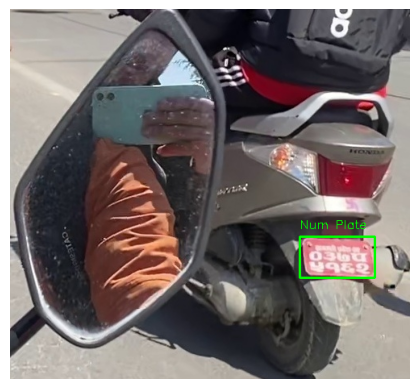

height:740 and width:1514


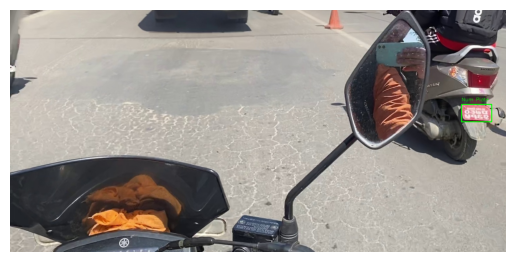

height:552 and width:565


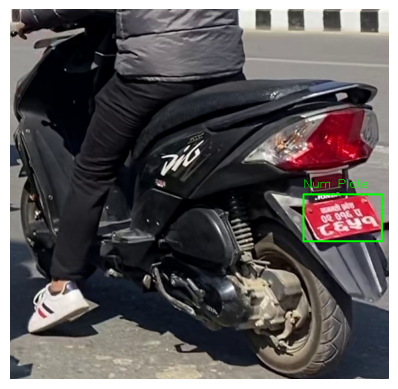

height:616 and width:539


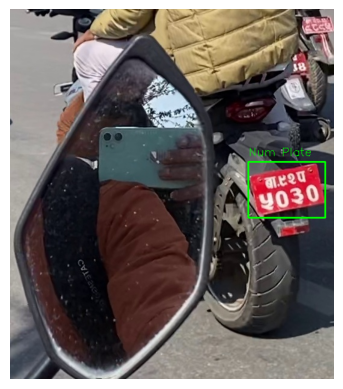

height:274 and width:103


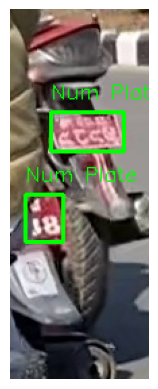

In [7]:
from IPython.display import Image #for displaying images
import os
import random
from sklearn.model_selection import train_test_split
from PIL import Image,ImageDraw
import numpy as np
import matplotlib.pyplot as plt
random.seed(42)
import cv2
image_dir =  "../train/images/"      # update your own path to images and labels(you can use any subfolders train,test,val) for checking
label_dir =  "../train/labels/"        

#function to load image
def load_image(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    return image
#function to lod labels and draw bounding boxes:
def load_label(image,label_path):
    height,width,_ = image.shape
    print(f'height:{height} and width:{width}')
    with open(label_path,"r") as f:
        lines = f.readlines()
        for line in lines:
            #yolo format : class,x_center,y_center,width,hight(normalized)
             class_id ,x_center,y_center,box_width,box_height = map(float,line.strip().split())
             x_center*=width
             y_center*=height
             box_width*= width
             box_height*=height

             #convert to top_left corner (x1,y1) and bottom_right corner(x2,y2)
             x1 = int(x_center-box_width/2)
             y1= int(y_center - box_height/2)
             x2 = int(x_center+box_width/2)
             y2 = int(y_center + box_height/2)
             #draw the bounding box
             cv2.rectangle(image,(x1,y1),(x2,y2),(0,255,0),2)
             font_scale = max(0.5,box_width/200)
             font_thickness=max(1,int(box_width/100))
             cv2.putText(image, 'Num Plate', (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX,font_scale, (0, 255, 0),font_thickness)
image_count =0
for image_filename in os.listdir(image_dir):
    if image_filename.endswith('.jpg'):
        image_path= os.path.join(image_dir,image_filename)
        label_path = os.path.join(label_dir,os.path.splitext(image_filename)[0]+'.txt')

        image = load_image(image_path)
        load_label(image,label_path)

        #display the image with bounding_box
        plt.imshow(image)
        plt.axis('off')
        plt.show()
        image_count +=1
        if image_count >=5:
            break



In [10]:
import os
os.environ["WANDB_NOTEBOOK_NAME"]:"project.ipynb"  # to include project.ipynb into wandb notebook

In [11]:
#!pip install wandb
import wandb
wandb.login(key="....")    #key provide by wandb

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\ACER\.netrc


True

In [12]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3050 Ti Laptop GPU


Now, it’s time to set up our options for training the network. We will make use of various flags to do so, including:

img-size: This parameter corresponds to the size of the image in pixels. For YOLOv7, The image must be square one.

batch: The batch size corresponds to the number of image-caption pairs being propagated through the network at any given time during training

epochs: Number of epochs to train for. This value corresponds to the total number of passes the model training will take across the entire dataset

data: The Data YAML file contains information about the dataset to help direct YOLO. Information inside includes path to the images, the number of class labels, and the names of the class labels. create a new .yaml file in my case num_plate.yaml.

workers: Indicates the number of CPU workers being allocated for training

cfg: The configuration file for the model architecture.

weights: Pretrained model weights we will want to re-start training from. If we want to train from scratch, we can just use --weights ' '

name: The path for various outputs about training such as train logs. The outputted training weights, logs, and samples of batched images are stored in a folder corresponding to runs/train/<name>.

hyp: YAML file that describes hyperparameter choices for the model training. For examples of how to define custom hyperparameters, see data/hyp.scratch.yaml. If unspecified, the hyperparameters in data/hyp.scratch.yaml is used.

In [ ]:
!python train.py --weights yolov7.pt  --workers 4 --data "data/num_plate.yaml" --batch-size 32 --device 0 --img 416 --cfg cfg/training/yolov7.yaml --name yolov7 --epochs 10 --hyp data/hyp.scratch.custom.yaml

2024-10-02 13:43:18.865442: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-02 13:43:18.900845: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-02 13:43:18.911744: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-02 13:43:18.935118: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-02 13:43:20.668323: W tensorflow/compiler/tf2

TEST:

In [ ]:
!python test.py --data "data/num_plate.yaml" --img 416 --batch-size 32 --conf 0.59 --iou 0.65 --device 0 --weights best.pt  --name yolov7test

Namespace(weights=['best.pt'], data='data/num_plate.yaml', batch_size=32, img_size=416, conf_thres=0.59, iou_thres=0.65, task='val', device='0', single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project='runs/test', name='yolov7test', exist_ok=False, no_trace=False, v5_metric=False)
YOLOR 🚀 v0.1-128-ga207844 torch 2.4.1+cu121 CUDA:0 (Tesla T4, 15102.0625MB)

/content/yolov7/models/experimental.py:252: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no lon

INFERENCING:

In [ ]:
!python detect.py --weights best.pt --source "../Num_Plate/video"   #the output are saved under exp folders of detect of runs of (updated)yolov7 main folder
                                                                     # use detect.py only for object localization

Namespace(weights=['best.pt'], source='../Num_Plate/video', img_size=640, conf_thres=0.25, iou_thres=0.45, device='', view_img=False, save_txt=False, save_conf=False, nosave=False, classes=None, agnostic_nms=False, augment=False, update=False, project='runs/detect', name='exp', exist_ok=False, no_trace=False)
YOLOR 🚀 v0.1-128-ga207844 torch 2.4.1+cu121 CUDA:0 (Tesla T4, 15102.0625MB)

/content/yolov7/models/experimental.py:252: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mod

In [ ]:
!python anpr.py --weights best.pt --source"/path"  #For detection and recognition using Easyocr 

In [21]:
!python ocr_detect.py --weights best.pt --source "test4" #For detection and recognition using our own OCR model

Namespace(weights=['best.pt'], source='imges', img_size=640, conf_thres=0.25, iou_thres=0.45, device='', view_img=False, save_txt=False, save_conf=False, nosave=False, classes=None, agnostic_nms=False, augment=False, update=False, project='runs/detect', name='exp', exist_ok=False, no_trace=False)
Fusing layers... 
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
IDetect.fuse
 Convert model to Traced-model... 
 traced_script_module saved! 
 model is traced! 

1 num_plate, Done. (16.3ms) Inference, (118.5ms) NMS
 The image with the result is saved in: runs\detect\exp31\test1.jpg
3 num_plates, Done. (16.6ms) Inference, (4.0ms) NMS
 The image with the result is saved in: runs\detect\exp31\test2.jpg
1 num_plate, Done. (20.2ms) Inference, (4.0ms) NMS
 The image with the result is saved in: runs\detect\exp31\test3.jpg
Done. (1.980s)


c:\Users\ACER\Documents\pandata\inpanda\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.2 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\ACER\Documents\pandata\inpanda\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.5.2 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\ACER\Documents\pandata\inpanda\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.5.2 when using version 1.4.2. This